# LNP Encapsulation Efficiency — Model Analysis & Explainability

This notebook documents the full analytical pipeline:
1. EDA — understanding the LNP Atlas dataset
2. Feature importance via SHAP
3. OOF prediction analysis (error breakdown)
4. Per-cargo-type performance
5. High-EE formulation patterns


In [9]:
import sys
from pathlib import Path

# Robustly find project root regardless of whether CWD is project root or notebooks/
_HERE = Path().resolve()
_ROOT = next(
    (p for p in [_HERE, _HERE.parent, _HERE.parent.parent] if (p / 'src').exists()),
    _HERE,
)
sys.path.insert(0, str(_ROOT / 'src'))

import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import shap

from features import build_feature_matrix, get_feature_columns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.2)
ARTIFACTS = _ROOT / 'artifacts'
DATA_PATH = _ROOT / 'data' / 'lnp_atlas_export.csv'

print(f'Project root: {_ROOT}')
print(f'Artifacts dir: {ARTIFACTS}')
print('Imports OK')

Project root: C:\Users\wslgi\OneDrive\Python Scripts\LNP Predictor
Artifacts dir: C:\Users\wslgi\OneDrive\Python Scripts\LNP Predictor\artifacts
Imports OK


## 1. Load Data & Build Features

In [10]:
df_raw = pd.read_csv(DATA_PATH, encoding='latin-1')
print(f'Raw rows: {len(df_raw)}')

df = build_feature_matrix(df_raw, drop_ee_na=True)
TARGET_COL = 'encapsulation_efficiency_percent_std'
feat_cols = get_feature_columns(df, TARGET_COL)

X = df[feat_cols].values
y = df[TARGET_COL].values
print(f'Usable rows: {len(df)} | Features: {len(feat_cols)}')

Raw rows: 1092


[23:07:17] SMILES Parse Error: unclosed ring for input: 'CCCCCCCCCCCC(O)CN1CCCCC(C(=O)NC2CCCCCNC(=O)C3N(CC(O)CCCCCCCCCCCC)CCC(CC3)N(CC(O)CCCCCCCCCCCC)CC(O)CCCCCCCCCCCC)C1'
[23:07:17] SMILES Parse Error: unclosed ring for input: 'CCCCCCCCCCCC(O)CN1CCCCC(C(=O)NC2CCCCCNC(=O)C3N(CC(O)CCCCCCCCCCCC)CCC(CC3)N(CC(O)CCCCCCCCCCCC)CC(O)CCCCCCCCCCCC)C1'
[23:07:17] SMILES Parse Error: unclosed ring for input: 'CCCCCCCCCCCC(O)CN1CCCCC(C(=O)NC2CCCCCNC(=O)C3N(CC(O)CCCCCCCCCCCC)CCC(CC3)N(CC(O)CCCCCCCCCCCC)CC(O)CCCCCCCCCCCC)C1'
[23:07:18] Explicit valence for atom # 31 C, 5, is greater than permitted


Usable rows: 523 | Features: 76


## 2. EDA — EE% Distribution

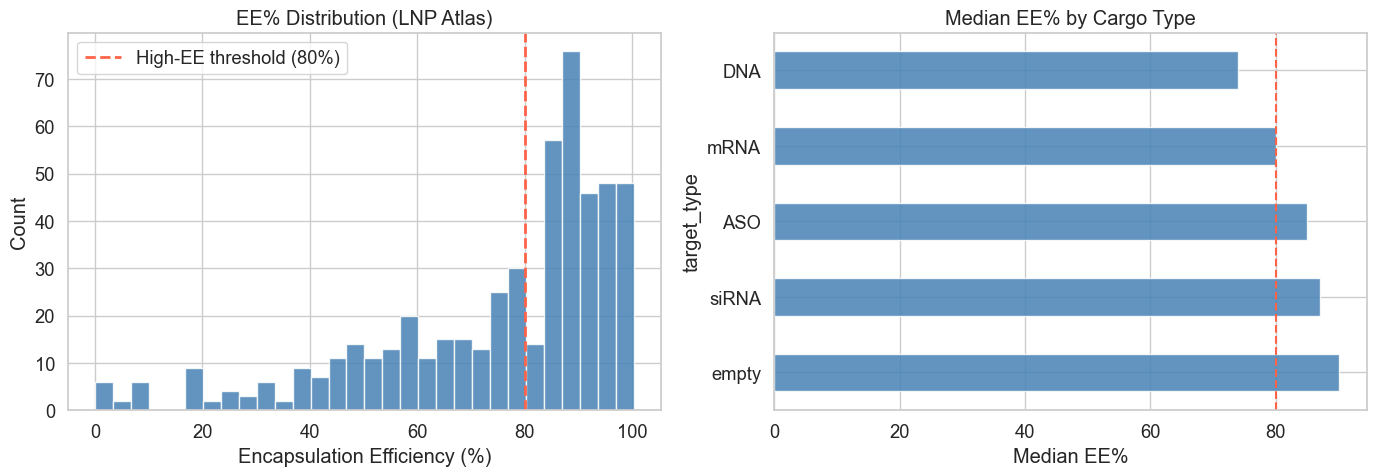

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(y, bins=30, edgecolor='white', color='steelblue', alpha=0.85)
axes[0].axvline(80, color='tomato', linestyle='--', linewidth=2, label='High-EE threshold (80%)')
axes[0].set_xlabel('Encapsulation Efficiency (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('EE% Distribution (LNP Atlas)')
axes[0].legend()

# By cargo type
cargo_ee = df.groupby('target_type')[TARGET_COL].median().sort_values(ascending=False)
cargo_ee.plot(kind='barh', ax=axes[1], color='steelblue', alpha=0.85)
axes[1].set_xlabel('Median EE%')
axes[1].set_title('Median EE% by Cargo Type')
axes[1].axvline(80, color='tomato', linestyle='--')

plt.tight_layout()
plt.savefig(ARTIFACTS / 'plots' / 'eda_ee_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Load Model & SHAP Values

In [12]:
with open(ARTIFACTS / 'model.pkl', 'rb') as f:
    model = pickle.load(f)

with open(ARTIFACTS / 'metadata.json') as f:
    metadata = json.load(f)

shap_values = np.load(ARTIFACTS / 'shap_values.npy')

transformer = None
transformer_path = ARTIFACTS / 'transformer.pkl'
print(f'transformer.pkl exists: {transformer_path.exists()}')
if transformer_path.exists():
    with open(transformer_path, 'rb') as f:
        transformer = pickle.load(f)

print('OOF Metrics:')
for k, v in metadata['oof_metrics'].items():
    print(f'  {k}: {v:.3f}')
print(f'Box-Cox transform: {metadata.get("box_cox_transform")} | transformer loaded: {transformer is not None}')

transformer.pkl exists: True
OOF Metrics:
  rmse: 21.240
  r2: 0.136
  mae: 15.375
  high_ee_precision: 0.866
  high_ee_recall: 0.429
  high_ee_f1: 0.573
Box-Cox transform: True | transformer loaded: True


## 4. SHAP Summary Plot

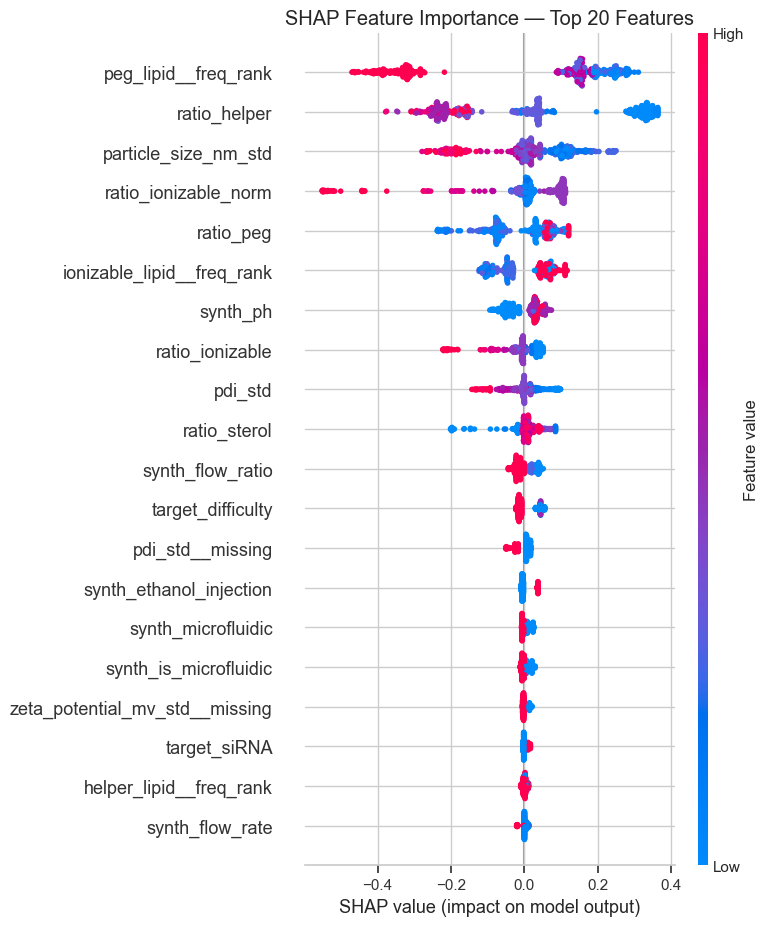

In [13]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X,
    feature_names=feat_cols,
    max_display=20,
    plot_type='dot',
    show=False
)
plt.title('SHAP Feature Importance — Top 20 Features')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'plots' / 'shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. OOF Prediction Analysis

preds_raw range: -1.5605 to 1.0604
after inverse_transform + clip: 41.48 to 96.25


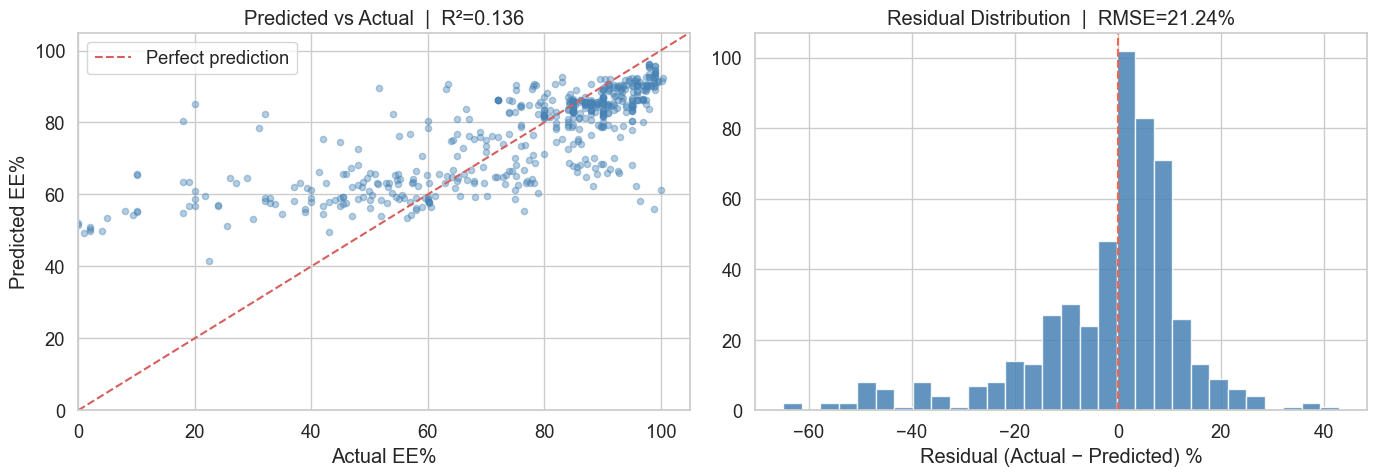

In [14]:
preds_raw = model.predict(X)
print(f'preds_raw range: {preds_raw.min():.4f} to {preds_raw.max():.4f}')

if transformer is not None:
    preds_inv = transformer.inverse_transform(preds_raw.reshape(-1, 1)).ravel()
    preds = np.clip(preds_inv, 0, 100)
    print(f'after inverse_transform + clip: {preds.min():.2f} to {preds.max():.2f}')
else:
    preds = preds_raw
    print('WARNING: transformer not loaded — predictions are in Box-Cox space, not EE%')

residuals = y - preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: predicted vs actual
axes[0].scatter(y, preds, alpha=0.4, s=20, color='steelblue')
lims = [0, 105]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlim(0, 105)
axes[0].set_ylim(0, 105)
axes[0].set_xlabel('Actual EE%')
axes[0].set_ylabel('Predicted EE%')
axes[0].set_title(f'Predicted vs Actual  |  R²={metadata["oof_metrics"]["r2"]:.3f}')
axes[0].legend()

# Residual distribution
axes[1].hist(residuals, bins=30, edgecolor='white', color='steelblue', alpha=0.85)
axes[1].axvline(0, color='tomato', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted) %')
axes[1].set_title(f'Residual Distribution  |  RMSE={metadata["oof_metrics"]["rmse"]:.2f}%')

plt.tight_layout()
plt.savefig(ARTIFACTS / 'plots' / 'oof_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Ionizable Lipid LogP vs EE% (key mechanistic insight)

<Figure size 800x500 with 0 Axes>

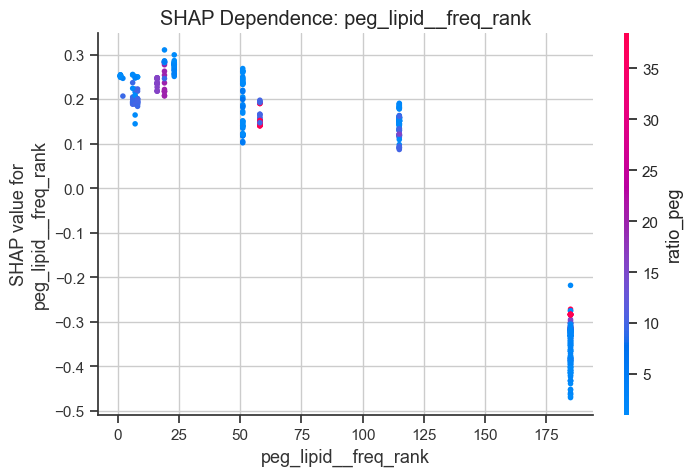

In [7]:
# SHAP dependence plot for the most important feature
top_feat = list(metadata['shap_top10'].keys())[0]
top_idx = feat_cols.index(top_feat)

plt.figure(figsize=(8, 5))
shap.dependence_plot(
    top_idx, shap_values, X,
    feature_names=feat_cols,
    show=False
)
plt.title(f'SHAP Dependence: {top_feat}')
plt.tight_layout()
plt.savefig(ARTIFACTS / 'plots' / 'shap_dependence_top.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. High-EE Formulation Patterns

In [8]:
df['predicted_ee'] = preds
df['is_high_ee'] = df[TARGET_COL] >= 80

print('=== Top ionizable lipids in High-EE formulations ===')
print(df[df['is_high_ee']]['ionizable_lipid'].value_counts().head(10))

print('\n=== Synthesis method comparison ===')
print(df.groupby('synth_method_cat')[TARGET_COL]
      .agg(['mean', 'median', 'count'])
      .sort_values('median', ascending=False))

=== Top ionizable lipids in High-EE formulations ===
ionizable_lipid
Custom lipid    122
DLin-MC3-DMA     44
DLin-KC2-DMA     25
C12-200          17
ALC-0315         14
OF-02            13
AX4              11
L202              8
DLinDMA           7
DOTAP             6
Name: count, dtype: int64

=== Synthesis method comparison ===
                        mean  median  count
synth_method_cat                           
nanoprecipitation  87.813725   93.60     51
ethanol_injection  85.302000   88.00     50
unknown            83.660000   85.00     25
microfluidic       71.343089   78.15    382
bulk               72.066667   70.00     15
